# Libraries

In [1]:
# Import all necessary libraries for data processing, modeling, and evaluation
import numpy as np
import os

# Import custom functions from the project modules
from src.data_ops import load_heart_disease_data, preprocess_heart_disease_data, find_outliers
from src.models import compare_model_statistics, pairwise_model_comparison, print_statistical_summary
from src.plots import plot_auc_boxplots, plot_hyperparameter_distributions, plot_continuous_distributions_with_qq, plot_correlation_heatmap, plot_most_misclassified_observations, get_misclassified_observations_details

print("All libraries imported successfully")

All libraries imported successfully


# Data Loading and Pre-Processing

DATA LOADING
Loading heart disease dataset from UCI repository
Dataset loaded successfully
  - Features shape: (303, 13)
  - Target shape: (303,)
  - Target distribution:
num
0    164
1    139
Name: count, dtype: int64

DATA PREPROCESSING
Preprocessing dataset
Number of NA values per column:
ca      4
thal    2
dtype: int64
Total NA values: 6
NA values removed

Outliers:

trestbps    9
chol        5
thalach     1
age         0
oldpeak     5
dtype: int64
Total outliers: 20

Observations with outliers: 19
Outlier observations saved to 'data/heart_disease_outliers.csv'

Dataset loaded successfully
  - Features shape: (303, 13)
  - Target shape: (303,)
  - Target distribution:
num
0    164
1    139
Name: count, dtype: int64

DATA PREPROCESSING
Preprocessing dataset
Number of NA values per column:
ca      4
thal    2
dtype: int64
Total NA values: 6
NA values removed

Outliers:

trestbps    9
chol        5
thalach     1
age         0
oldpeak     5
dtype: int64
Total outliers: 20

Observation

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,outlier_features
14,52,1,3,172,199,1,0,162,0,0.5,1,0.0,7.0,0,trestbps
48,65,0,3,140,417,1,2,157,0,0.8,1,1.0,3.0,0,chol
83,68,1,3,180,274,1,2,150,1,1.6,2,0.0,7.0,1,trestbps
91,62,0,4,160,164,0,2,145,0,6.2,3,3.0,7.0,1,oldpeak
121,63,0,4,150,407,0,2,154,0,4.0,2,3.0,7.0,1,chol
123,55,1,4,140,217,0,0,111,1,5.6,3,0.0,7.0,1,oldpeak
126,56,0,4,200,288,1,2,133,1,4.0,3,2.0,7.0,1,trestbps
152,67,0,3,115,564,0,2,160,0,1.6,2,0.0,7.0,0,chol
172,59,0,4,174,249,0,0,143,1,0.0,2,0.0,3.0,1,trestbps
173,62,0,4,140,394,0,2,157,0,1.2,2,0.0,3.0,0,chol



Preprocessing completed
  - Final dataset shape: (297, 14)
  - Number of features: 13
  - Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Plot distribution and qq-plots of continuous features


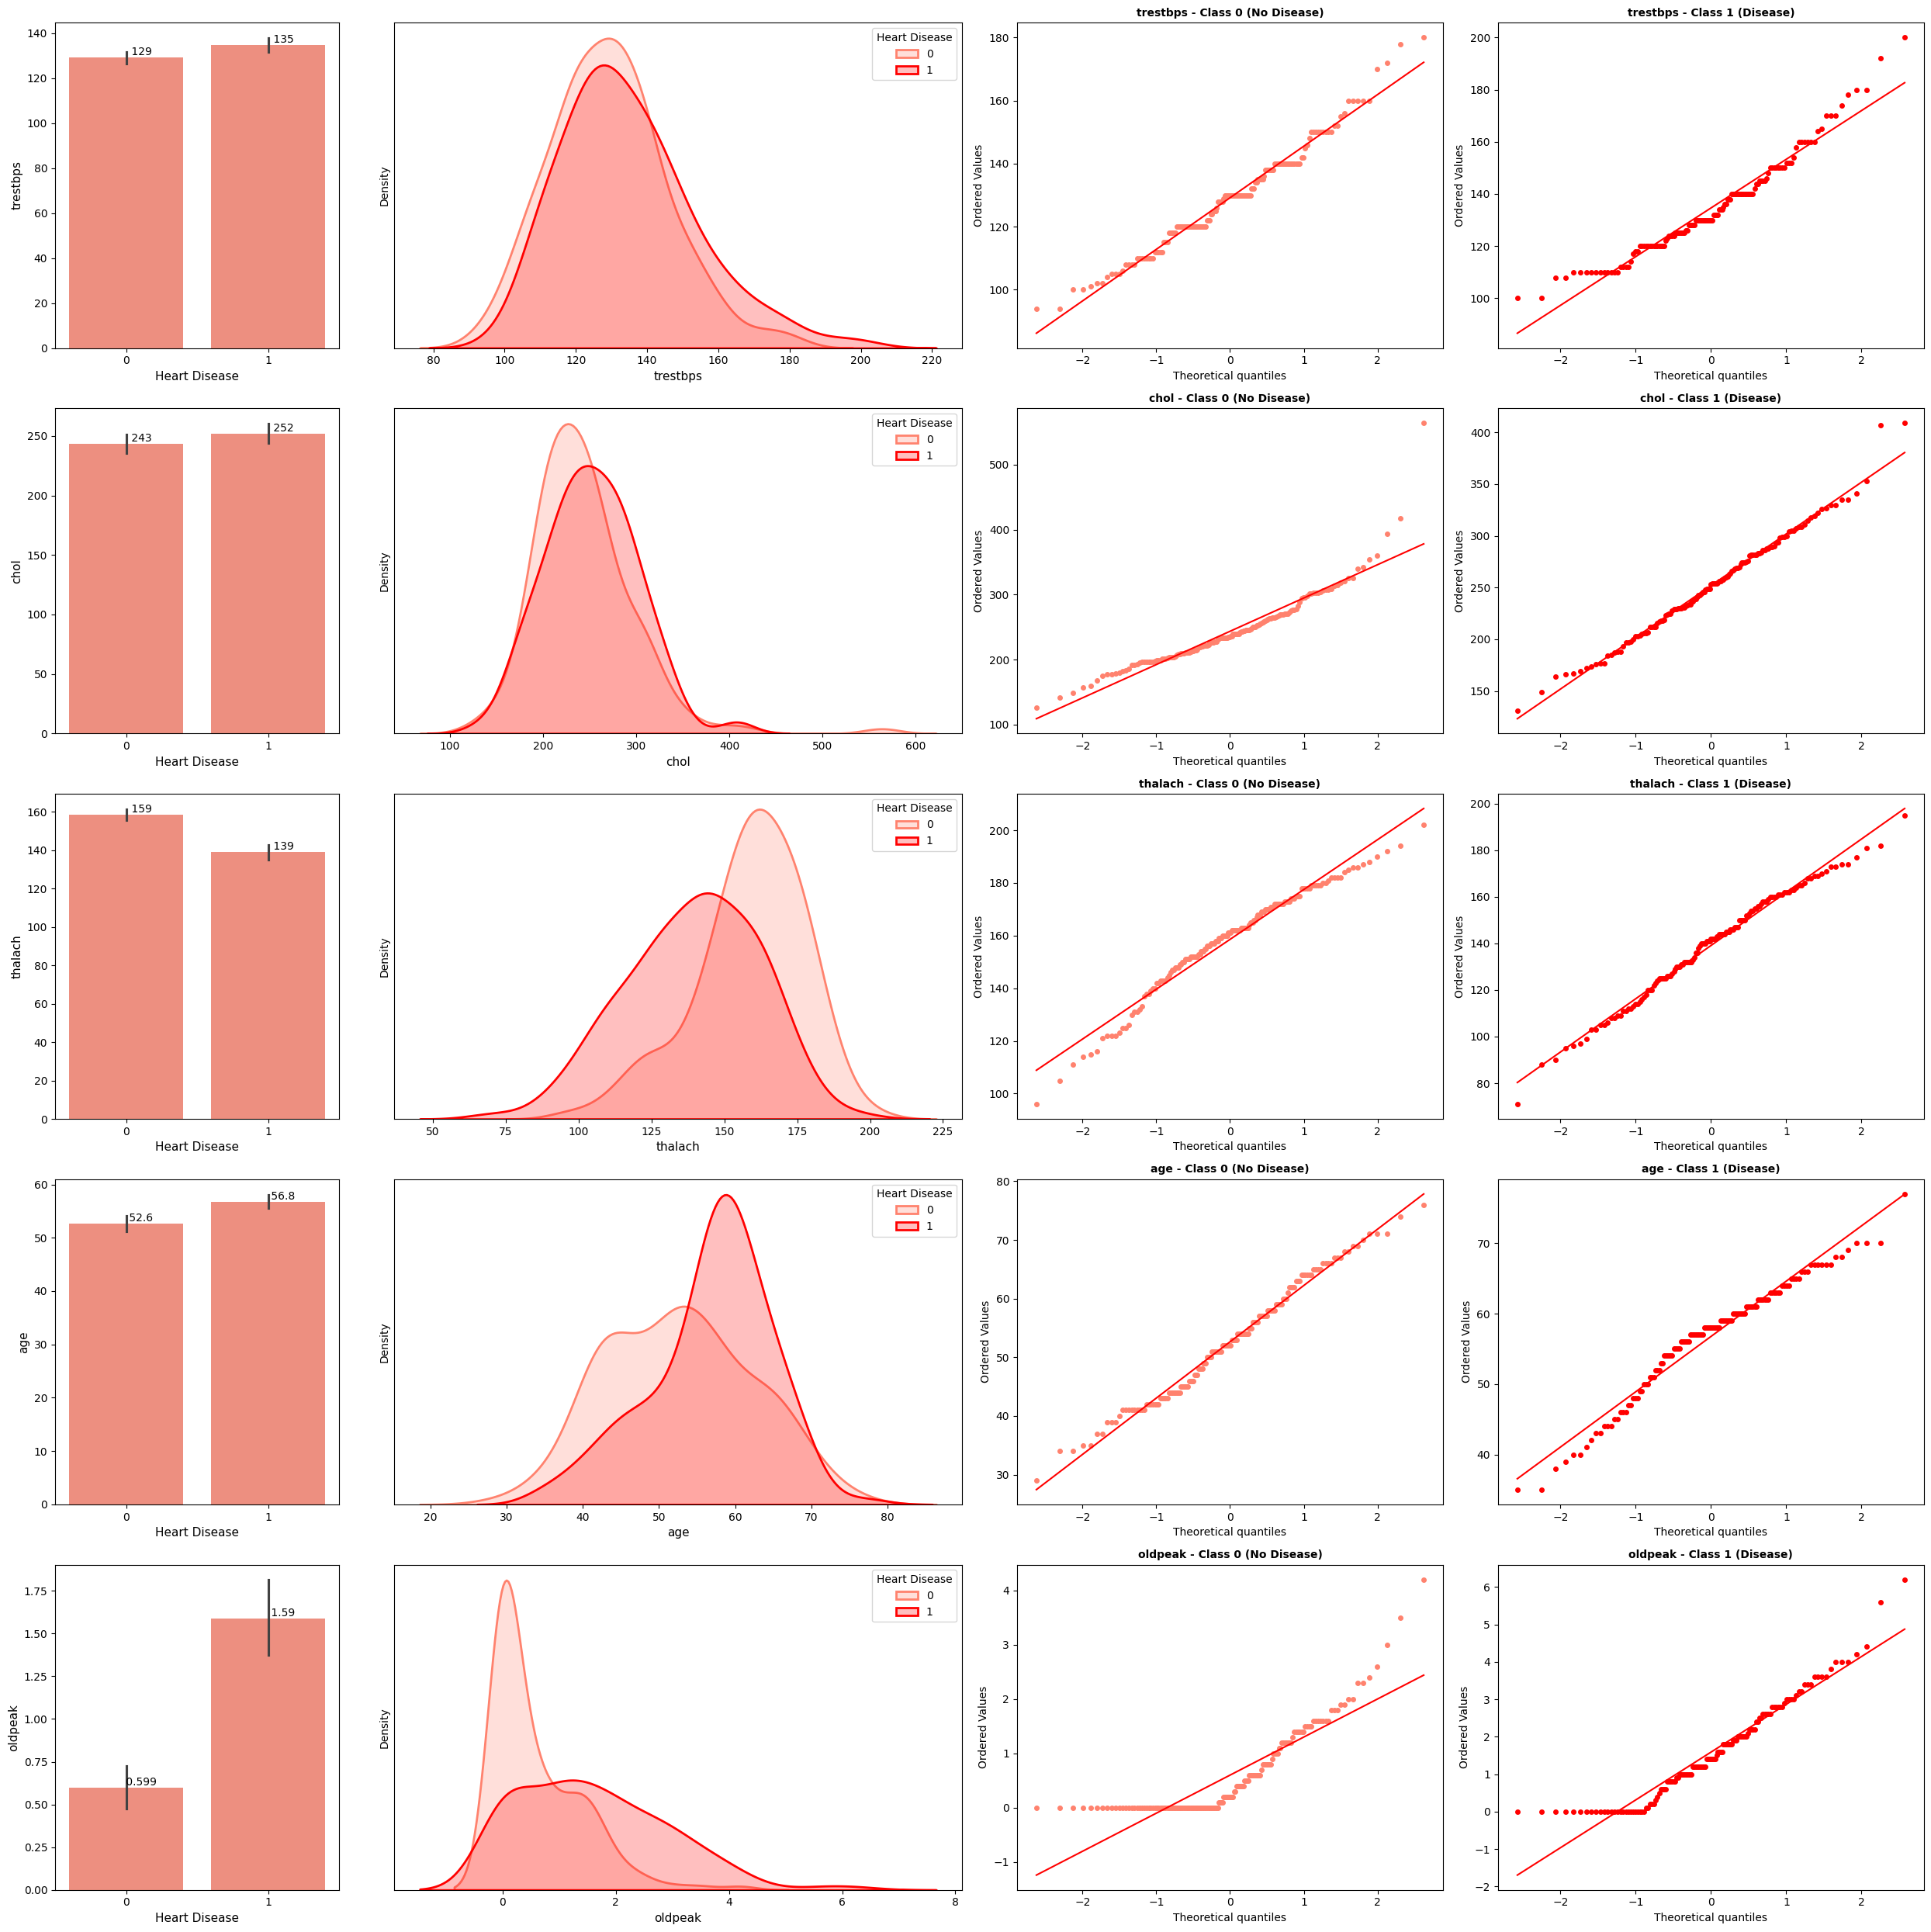

In [2]:
print("=" * 80)
print("DATA LOADING")
print("=" * 80)

# Create necessary directories for storing results and visualizations
os.makedirs("data", exist_ok=True) 
os.makedirs("img", exist_ok=True)

# Set random seed for reproducibility
np.random.seed(42)

print("Loading heart disease dataset from UCI repository")
X, y = load_heart_disease_data()
print(f"Dataset loaded successfully")
print(f"  - Features shape: {X.shape}")
print(f"  - Target shape: {y.shape}")
print(f"  - Target distribution:\n{y.value_counts()}\n")

print("=" * 80)
print("DATA PREPROCESSING")
print("=" * 80)

print("Preprocessing dataset")
dataset = preprocess_heart_disease_data(X, y)

print("Outliers:" + "\n")
outliers_count, outliers_df = find_outliers(dataset)
print(outliers_count)
print("Total outliers: " + str(sum(outliers_count)) + "\n")

print(f"Observations with outliers: {len(outliers_df)}")
print(f"Outlier observations saved to 'data/heart_disease_outliers.csv'\n")
outliers_df.to_csv('data/heart_disease_outliers.csv', index=True)
display(outliers_df)

print(f"\nPreprocessing completed")
print(f"  - Final dataset shape: {dataset.shape}")
print(f"  - Number of features: {dataset.shape[1] - 1}")
print(f"  - Features: {list(dataset.drop('num', axis=1).columns)}\n")

print("Plot distribution and qq-plots of continuous features")
plot_continuous_distributions_with_qq(dataset)

Plot correlation heatmap of continuous features


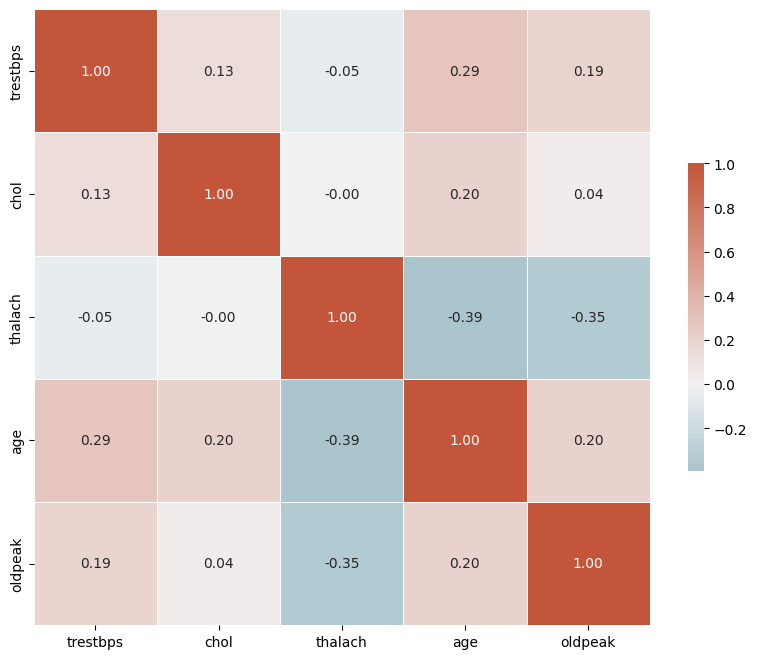

In [3]:
print("Plot correlation heatmap of continuous features")
plot_correlation_heatmap(dataset)

# Models Testing


PERFORMING MODEL SELECTION AND HYPERPARAMETER TUNING ON A RANGE OF MODELS TO COMPARE THEIR AVERAGE STATISTICS
Computing models cross validation statistics over multiple rounds

PERFORMANCE ANALYSIS
Average performance metrics comparison results:

PERFORMANCE ANALYSIS
Average performance metrics comparison results:


,Model,Mean AUC,Training Time (ms)
0,Logistic Regression,0.906 ± 0.003,0.51601 ± 0.00299
1,Custom Naive Bayes,0.897 ± 0.004,5.28421 ± 0.20620
2,Decision Trees,0.818 ± 0.005,0.54616 ± 0.00437
3,SVM,0.903 ± 0.003,3.93576 ± 0.13773



PAIRWISE STATISTICAL COMPARISON OF MODELS (Paired t-test with Bonferroni)

Logistic Regression vs Custom Naive Bayes:
  Mean Difference: 0.0093 ± 0.0222
  t-statistic: 4.1878
  p-value: 0.000061
  Significant (α = 0.008333): Yes

Logistic Regression vs Decision Trees:
  Mean Difference: 0.0884 ± 0.0418
  t-statistic: 21.1523
  p-value: 0.000000
  Significant (α = 0.008333): Yes

Logistic Regression vs SVM:
  Mean Difference: 0.0038 ± 0.0119
  t-statistic: 3.1834
  p-value: 0.001946
  Significant (α = 0.008333): Yes

Custom Naive Bayes vs Decision Trees:
  Mean Difference: 0.0791 ± 0.0462
  t-statistic: 17.1052
  p-value: 0.000000
  Significant (α = 0.008333): Yes

Custom Naive Bayes vs SVM:
  Mean Difference: -0.0055 ± 0.0201
  t-statistic: -2.7370
  p-value: 0.007351
  Significant (α = 0.008333): Yes

Decision Trees vs SVM:
  Mean Difference: -0.0846 ± 0.0415
  t-statistic: -20.3570
  p-value: 0.000000
  Significant (α = 0.008333): Yes


Significant differences found in 6 comparison(

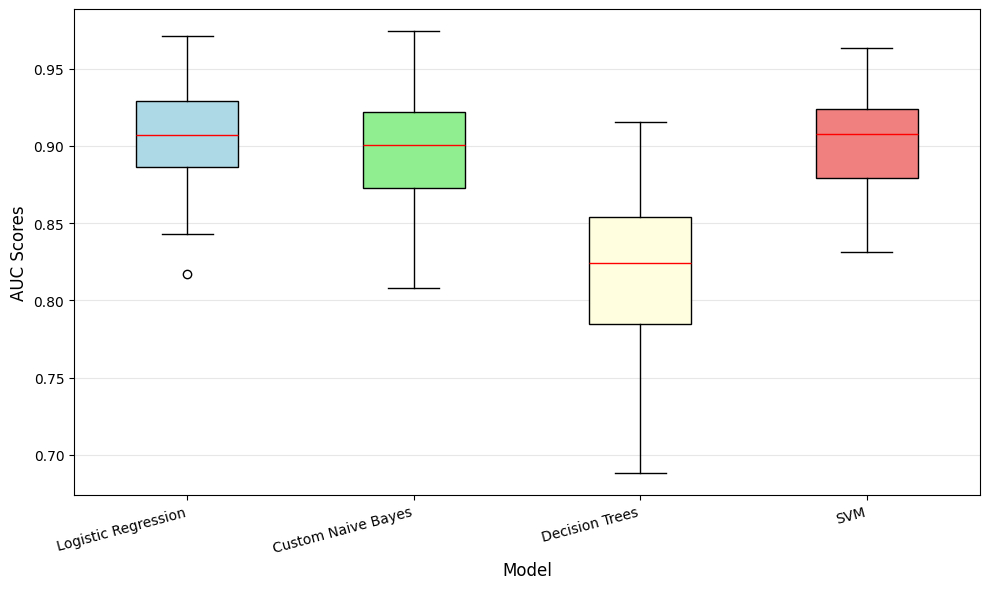

Hyperparameter distribution for each model:


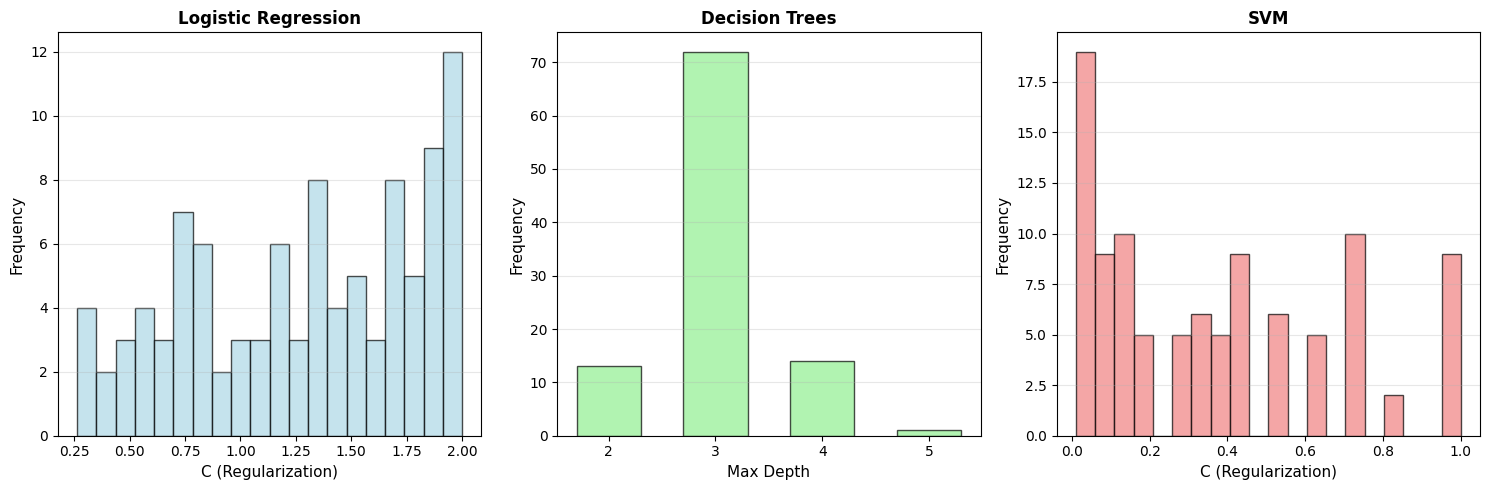

In [4]:
print("\n" + "=" * 80)
print("PERFORMING MODEL SELECTION AND HYPERPARAMETER TUNING ON A RANGE OF MODELS TO COMPARE THEIR AVERAGE STATISTICS")
print("=" * 80)

print("Computing models cross validation statistics over multiple rounds")
comparison_results, average_comparison_results = compare_model_statistics(dataset, n_rounds=100)

print("\n" + "=" * 80)
print("PERFORMANCE ANALYSIS")
print("=" * 80)

print("Average performance metrics comparison results:")
display(average_comparison_results)

comparison_df = pairwise_model_comparison(comparison_results, alpha=0.05)

print_statistical_summary(comparison_df)

print("Distribution of the AUC values for each model:")
plot_auc_boxplots(comparison_results)

print("Hyperparameter distribution for each model:")
plot_hyperparameter_distributions(comparison_results)


MISCLASSIFICATION ANALYSIS
Analyzing the most frequently misclassified observations across all rounds


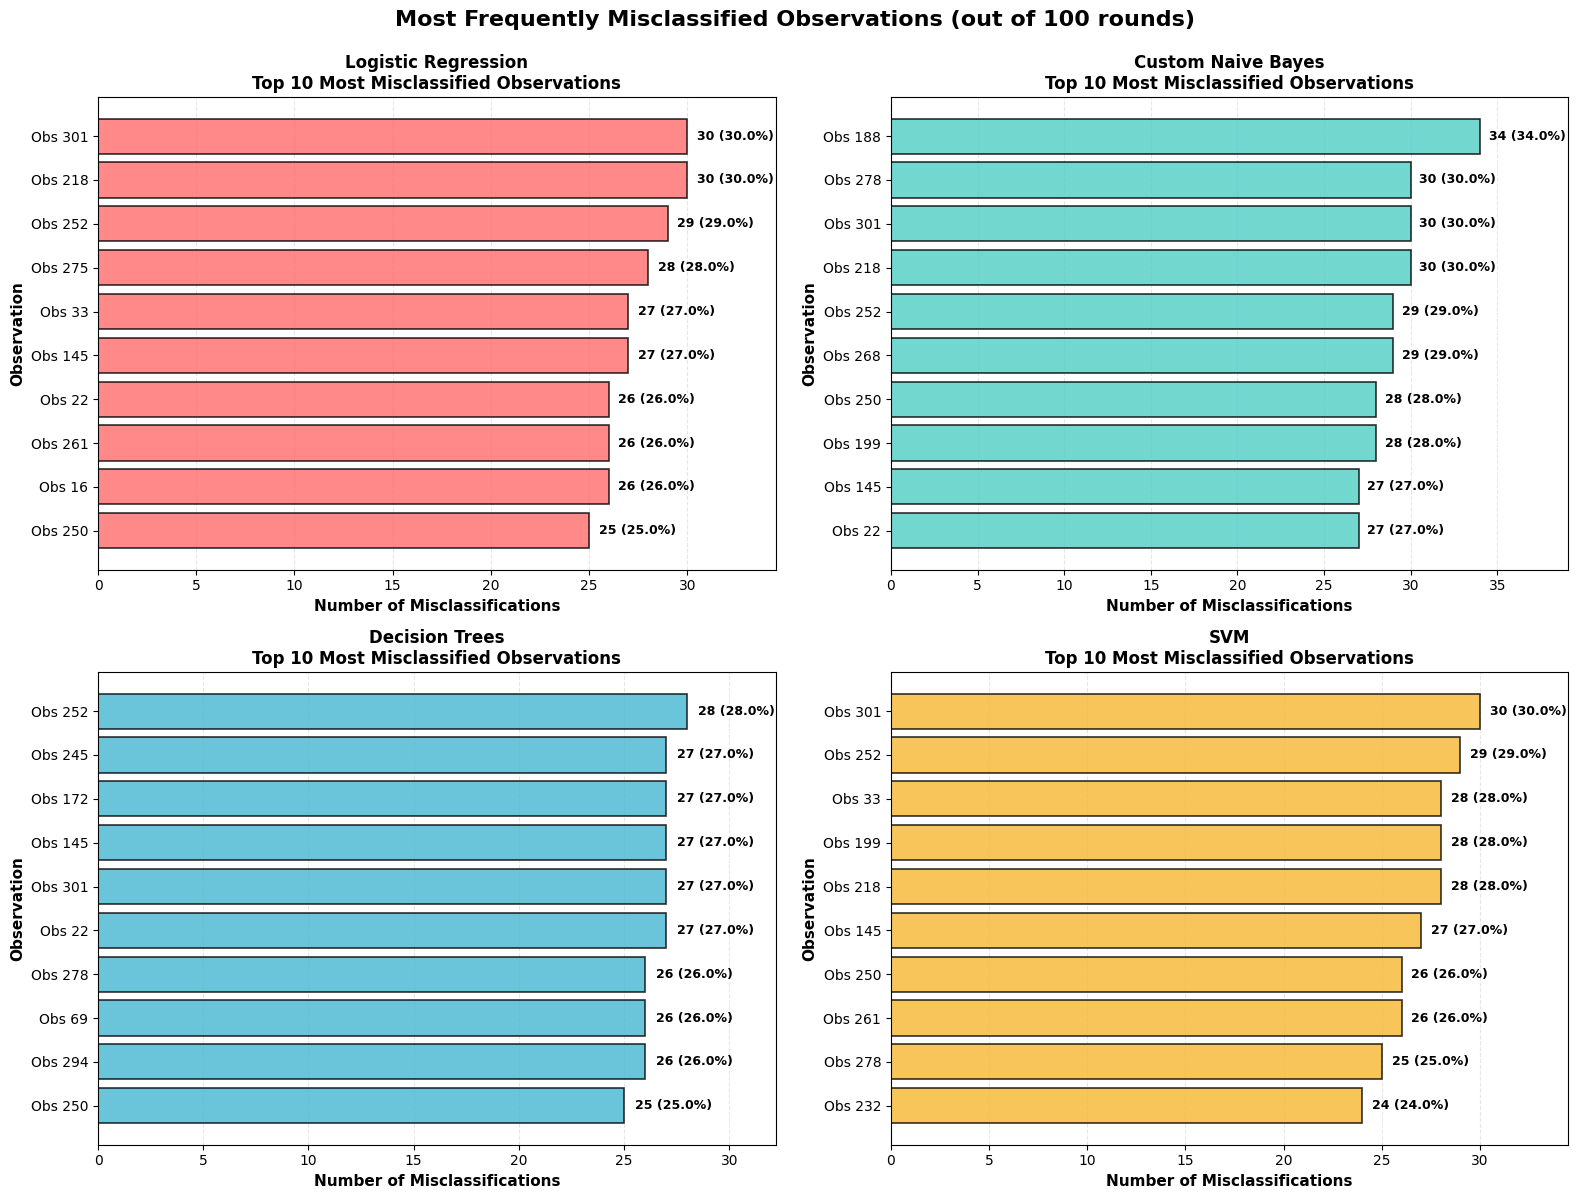


Retrieving full details of the most misclassified observations
Saved Logistic Regression most misclassified observations to data/most_misclassified_logistic_regression.csv
Saved Custom Naive Bayes most misclassified observations to data/most_misclassified_custom_naive_bayes.csv
Saved Decision Trees most misclassified observations to data/most_misclassified_decision_trees.csv
Saved SVM most misclassified observations to data/most_misclassified_svm.csv

MOST MISCLASSIFIED OBSERVATIONS DETAILS

Logistic Regression:
--------------------------------------------------------------------------------


,Misclassification Count,Percentage,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
301,30,30.0,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0,1
218,30,30.0,64,0,4,130,303,0,0,122,0,2.0,2,2.0,3.0,0
252,29,29.0,64,1,4,128,263,0,0,105,1,0.2,2,1.0,7.0,0
275,28,28.0,64,1,1,170,227,0,2,155,0,0.6,2,0.0,7.0,0
33,27,27.0,59,1,4,135,234,0,0,161,0,0.5,2,0.0,7.0,0
145,27,27.0,47,1,3,108,243,0,0,152,0,0.0,1,0.0,3.0,1
22,26,26.0,58,1,2,120,284,0,2,160,0,1.8,2,0.0,3.0,1
261,26,26.0,58,0,2,136,319,1,2,152,0,0.0,1,2.0,3.0,1
16,26,26.0,48,1,2,110,229,0,0,168,0,1.0,3,0.0,7.0,1
250,25,25.0,57,1,4,110,201,0,0,126,1,1.5,2,0.0,6.0,0




Custom Naive Bayes:
--------------------------------------------------------------------------------


,Misclassification Count,Percentage,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
188,34,34.0,54,1,2,192,283,0,2,195,0,0.0,1,1.0,7.0,1
278,30,30.0,57,1,2,154,232,0,2,164,0,0.0,1,1.0,3.0,1
301,30,30.0,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0,1
218,30,30.0,64,0,4,130,303,0,0,122,0,2.0,2,2.0,3.0,0
252,29,29.0,64,1,4,128,263,0,0,105,1,0.2,2,1.0,7.0,0
268,29,29.0,40,1,4,152,223,0,0,181,0,0.0,1,0.0,7.0,1
250,28,28.0,57,1,4,110,201,0,0,126,1,1.5,2,0.0,6.0,0
199,28,28.0,59,1,1,160,273,0,2,125,0,0.0,1,0.0,3.0,1
145,27,27.0,47,1,3,108,243,0,0,152,0,0.0,1,0.0,3.0,1
22,27,27.0,58,1,2,120,284,0,2,160,0,1.8,2,0.0,3.0,1




Decision Trees:
--------------------------------------------------------------------------------


,Misclassification Count,Percentage,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
252,28,28.0,64,1,4,128,263,0,0,105,1,0.2,2,1.0,7.0,0
245,27,27.0,67,1,4,120,237,0,0,71,0,1.0,2,0.0,3.0,1
172,27,27.0,59,0,4,174,249,0,0,143,1,0.0,2,0.0,3.0,1
145,27,27.0,47,1,3,108,243,0,0,152,0,0.0,1,0.0,3.0,1
301,27,27.0,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0,1
22,27,27.0,58,1,2,120,284,0,2,160,0,1.8,2,0.0,3.0,1
278,26,26.0,57,1,2,154,232,0,2,164,0,0.0,1,1.0,3.0,1
69,26,26.0,46,1,3,150,231,0,0,147,0,3.6,2,0.0,3.0,1
294,26,26.0,63,0,4,124,197,0,0,136,1,0.0,2,0.0,3.0,1
250,25,25.0,57,1,4,110,201,0,0,126,1,1.5,2,0.0,6.0,0




SVM:
--------------------------------------------------------------------------------


,Misclassification Count,Percentage,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
301,30,30.0,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0,1
252,29,29.0,64,1,4,128,263,0,0,105,1,0.2,2,1.0,7.0,0
33,28,28.0,59,1,4,135,234,0,0,161,0,0.5,2,0.0,7.0,0
199,28,28.0,59,1,1,160,273,0,2,125,0,0.0,1,0.0,3.0,1
218,28,28.0,64,0,4,130,303,0,0,122,0,2.0,2,2.0,3.0,0
145,27,27.0,47,1,3,108,243,0,0,152,0,0.0,1,0.0,3.0,1
250,26,26.0,57,1,4,110,201,0,0,126,1,1.5,2,0.0,6.0,0
261,26,26.0,58,0,2,136,319,1,2,152,0,0.0,1,2.0,3.0,1
278,25,25.0,57,1,2,154,232,0,2,164,0,0.0,1,1.0,3.0,1
232,24,24.0,49,1,3,118,149,0,2,126,0,0.8,1,3.0,3.0,1


In [5]:
print("\n" + "=" * 80)
print("MISCLASSIFICATION ANALYSIS")
print("=" * 80)

print("Analyzing the most frequently misclassified observations across all rounds")
top_misclassified = plot_most_misclassified_observations(comparison_results, top_n=10)

print("\nRetrieving full details of the most misclassified observations")
misclassified_details = get_misclassified_observations_details(dataset, top_misclassified)

print("\n" + "=" * 80)
print("MOST MISCLASSIFIED OBSERVATIONS DETAILS")
print("=" * 80)

for model_name, obs_df in misclassified_details.items():
    print(f"\n{model_name}:")
    print("-" * 80)
    display(obs_df)
    print()